In [5]:
getwd()

[1] "/home/user/Capstone Project on Elephant Mortality Rate"

In [7]:

create_project_structure <- function(project_name) {
  "Create a clean GitHub-ready project structure"
 
  # Create main project folder
  dir.create(project_name, showWarnings = FALSE)
 
  # Define 6 top-level folders
  folders <- c(
    "data_raw",
    "data_processed",
    "scripts",
    "analysis",
    "outputs",
    "docs"
  )
 
  # Create folders + README
  for (folder in folders) {
    folder_path <- file.path(project_name, folder)
    dir.create(folder_path, showWarnings = FALSE)
   
    readme_path <- file.path(folder_path, "README.md")
   
    if (folder == "data_raw") {
      writeLines(
        c("# Raw Data",
          "⚠️ Do NOT modify raw data.",
          "Store original elephant mortality datasets here."),
        readme_path
      )
    } else if (folder == "data_processed") {
      writeLines(
        c("# Processed Data",
          "Cleaned and transformed datasets.",
          "Document all processing steps."),
        readme_path
      )
    } else if (folder == "scripts") {
      writeLines(
        c("# Scripts",
          "All R/Python scripts.",
          "Use version control (git)."),
        readme_path
      )
    } else if (folder == "analysis") {
      writeLines(
        c("# Analysis",
          "Notebooks, exploratory analysis, modeling."),
        readme_path
      )
    } else if (folder == "outputs") {
      writeLines(
        c("# Outputs",
          "Figures, maps, results for reports."),
        readme_path
      )
    } else if (folder == "docs") {
      writeLines(
        c("# Documentation",
          "Project notes, metadata, methods."),
        readme_path
      )
    }
  }
 
  cat("\n✅ Created project structure:\n")
  print(list.dirs(project_name, recursive = TRUE, full.names = FALSE))
 
  return(invisible(TRUE))
}

# Run it
create_project_structure("Elephant_mortality_rate")


✅ Created project structure:
[1] ""               "analysis"       "data_processed" "data_raw"      
[5] "docs"           "outputs"        "scripts"       


In [3]:
# Load Required Libraries

# Load packages
library(tidyverse)   # Includes ggplot2, dplyr, readr
library(scales)      # For axis formatting
library(ggthemes)    # Optional themes
library(readxl)      # For Excel files
library(lubridate)   # For dates
library(sf)          # For spatial data
library(janitor)     # For cleaning column names

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard




The following object is masked from ‘package:readr’:

    col_factor




Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE




Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [19]:
# LOAD THE DATASET
# Read the Excel file

data <- read_excel("MIKE data_Laikipia Samburu_harmonisation_230216 (1).xlsx",
                   sheet = "mike2015_191records") # Matches file content

data$DATE <- as.Date(as.numeric(data$DATE), origin = "1899-12-30") #To avoid the excel giving dates in Excel serial date

head(data)  # Check first rows
str(data)   # Check structure


Warning message in as.Date(as.numeric(data$DATE), origin = "1899-12-30"):
“NAs introduced by coercion”


sort,Mapindex,DATE,Month of death,Year,ETD,Carcass age,Quarter,Conservation Area,POST,⋯,AWF ID,Mt. Kenya Trust,Samburu Trust,AGE,SEX,TUSK STATUS,Tusks Simp,Notes 1 - Remarks,Notes 2 -Weight,Note 3 - Follow up
<dbl>,<chr>,<date>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
16,2015/16,2015-01-31,January,2015,NA,Fresh,1,Mountain,NA,⋯,NA,NA,NA,NA,Male,Missing,Missing,NA,NA,NA
91,2015/91,2015-06-18,June,2015,NA,Fresh,2,Mountain,NA,⋯,NA,NA,NA,NA,Male,NA,Present,Intact Weighing0.25kgs Each,NA,NA
116,2015/116,2015-08-21,August,2015,NA,Fresh,3,Mountain,NA,⋯,NA,NA,NA,NA,Male,Intact,Present,Intact Weighing 10 Kgs And 11 Kgs,NA,NA
117,2015/117,2015-08-24,August,2015,NA,Fresh,3,Mountain,NA,⋯,NA,NA,NA,NA,Male,Intact,Present,Intact Weighing 7kgs Each,NA,NA
125,2015/125,2015-09-09,September,2015,NA,Fresh,3,Mountain,NA,⋯,NA,NA,NA,NA,Male,Intact,Present,Intact Weighing 7.5kgs And 1.5kgs Each.,NA,NA
130,2015/130,2015-09-15,September,2015,NA,Fresh,3,Mountain,NA,⋯,NA,NA,NA,NA,Male,Intact,Present,Inner Part Intact Weighing2.25 Kgs While Outer Part Missing[Cut],NA,NA


tibble [191 × 42] (S3: tbl_df/tbl/data.frame)
 $ sort                     : num [1:191] 16 91 116 117 125 130 134 136 29 39 ...
 $ Mapindex                 : chr [1:191] "2015/16" "2015/91" "2015/116" "2015/117" ...
 $ DATE                     : Date[1:191], format: "2015-01-31" "2015-06-18" ...
 $ Month of death           : chr [1:191] "January" "June" "August" "August" ...
 $ Year                     : num [1:191] 2015 2015 2015 2015 2015 ...
 $ ETD                      : chr [1:191] NA NA NA NA ...
 $ Carcass age              : chr [1:191] "Fresh" "Fresh" "Fresh" "Fresh" ...
 $ Quarter                  : num [1:191] 1 2 3 3 3 3 3 3 1 1 ...
 $ Conservation Area        : chr [1:191] "Mountain" "Mountain" "Mountain" "Mountain" ...
 $ POST                     : chr [1:191] NA NA NA NA ...
 $ County                   : chr [1:191] NA NA NA NA ...
 $ AREA                     : chr [1:191] "Longishu" "Sabariwawa" "Sarara" "Leparua" ...
 $ Area Simplified          : chr [1:191] "Nasulu Cons

In [5]:

# STEP 3: Data Cleaning (handle "Unknown", select key vars)

data_clean <- data %>%
  clean_names() %>%  # Makes names like "cause_of_death_simplified"
  select(date, month_of_death, year, county, conservation_area,
         cause_of_death_simplified, age, sex, latitude, longitude,
         cause_raw, reason, means, pike_tally) %>%  # Key vars for questions


  # Replace "Unknown"/"UNKNOWN"/blanks with NA
  mutate(across(c(cause_of_death_simplified, conservation_area, county, age, sex, 
                  cause_raw, reason, means), ~ {
                    ifelse(tolower(trimws(as.character(.))) %in% c("unknown", ""), NA, .)
                  })) %>%
  filter(year == 2015, !is.na(cause_of_death_simplified)) %>%  # Filter 2015, drop missing causes


  # Date parsing fix: Use ymd_hms or parse flexibly
  mutate(date = ymd_hms(date, quiet = TRUE))  # Handles "2015-01-31 000000"


summary(data_clean)  # Check cleaned data (should have ~165 rows after cleaning)
nrow(data_clean)

      date     month_of_death          year         county         
 Min.   :NA    Length:165         Min.   :2015   Length:165        
 1st Qu.:NA    Class :character   1st Qu.:2015   Class :character  
 Median :NA    Mode  :character   Median :2015   Mode  :character  
 Mean   :NaN                      Mean   :2015                     
 3rd Qu.:NA                       3rd Qu.:2015                     
 Max.   :NA                       Max.   :2015                     
 NA's   :165                                                       
 conservation_area  cause_of_death_simplified     age           
 Length:165         Length:165                Length:165        
 Class :character   Class :character          Class :character  
 Mode  :character   Mode  :character          Mode  :character  
                                                                
                                                                
                                                                
 

[1] 165

In [7]:
# CAUSE OF DEATH ANALSIS (RQ1)

cause_summary <- data_clean %>%
  count(cause_of_death_simplified, sort = TRUE)
print(cause_summary)

# A tibble: 4 × 2
  cause_of_death_simplified     n
  <chr>                     <int>
1 Natural                      89
2 Poached                      45
3 H/E Conflict                 29
4 PAC                           2


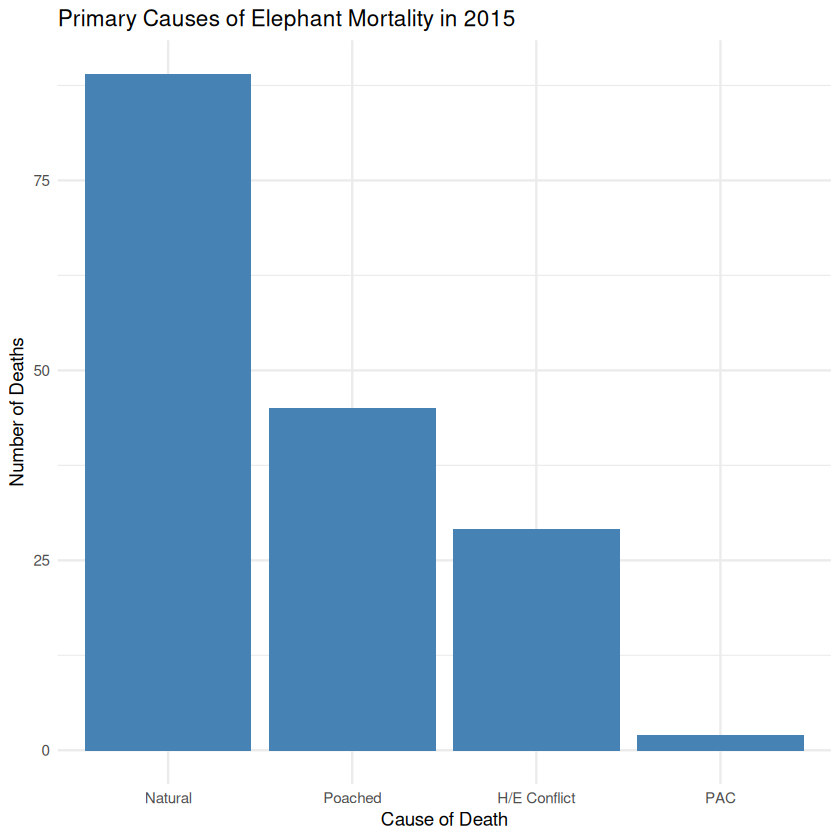

In [8]:
 # Bar chart: Causes of elephant mortality (RQ1) 
ggplot(cause_summary, aes(x = reorder(cause_of_death_simplified, -n), y = n)) +
geom_col(fill = "steelblue") +
labs( title = "Primary Causes of Elephant Mortality in 2015", 
     x = "Cause of Death",
     y = "Number of Deaths" ) +
theme_minimal()

In [9]:
# STEP 5: Spatial Comparison (RQ2)
# By Conservation Area
area_summary <- data_clean %>%
  count(conservation_area, cause_of_death_simplified, sort = TRUE)
print(area_summary)

# A tibble: 4 × 3
  conservation_area cause_of_death_simplified     n
  <chr>             <chr>                     <int>
1 Mountain          Natural                      89
2 Mountain          Poached                      45
3 Mountain          H/E Conflict                 29
4 Mountain          PAC                           2


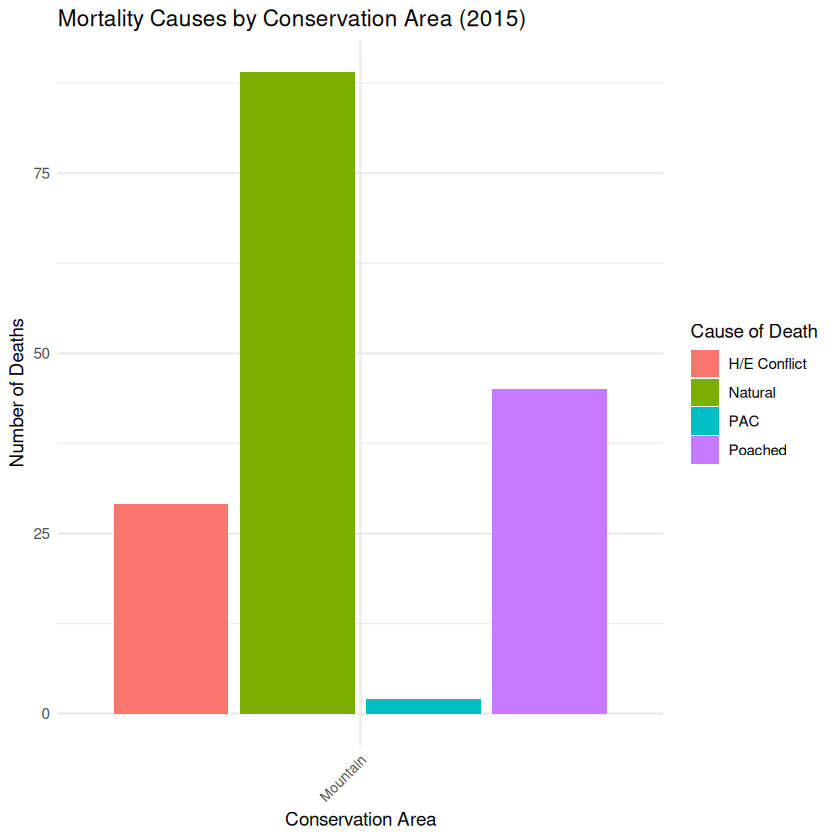

In [10]:
# By Conservation Area (RQ2) with dodged vertical bars

ggplot(area_summary, aes(x = conservation_area, y = n, fill = cause_of_death_simplified)) +
  geom_col(position = position_dodge(width = 1)) +  # increase width to 1
  labs(title = "Mortality Causes by Conservation Area (2015)",
       x = "Conservation Area",
       y = "Number of Deaths",
       fill = "Cause of Death") +
  theme_minimal() +
  theme(axis.text.x = element_text(size = 8, angle = 45, hjust = 1))

# A tibble: 7 × 3
  county   cause_of_death_simplified     n
  <chr>    <chr>                     <int>
1 Isiolo   Natural                       1
2 Laikipia H/E Conflict                  6
3 Laikipia Natural                       9
4 Laikipia Poached                       9
5 Samburu  H/E Conflict                  2
6 Samburu  Natural                       8
7 Samburu  Poached                       3


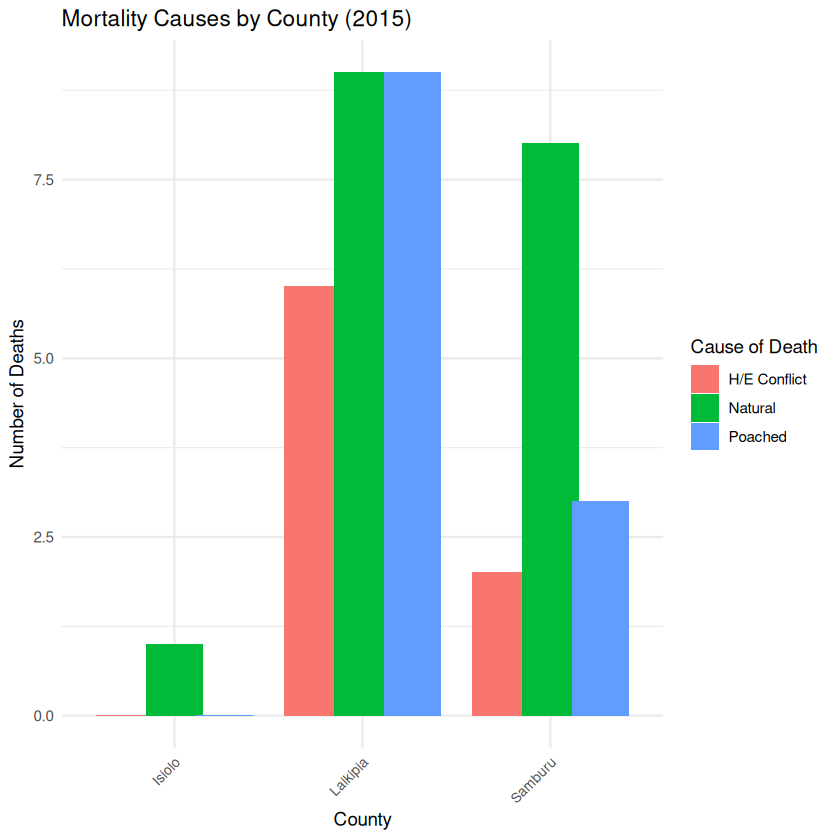

In [11]:
# By County, remove rows with NA in 'county' (RQ2)

county_summary <- data_clean %>%
  filter(!is.na(county)) %>%       # Remove NAs in county
  count(county, cause_of_death_simplified)

print(county_summary)  # Check the summary

# Load tidyr to use complete()
library(tidyr)

# Make sure every county has all causes (fill missing with 0)
county_summary_complete <- county_summary %>% 
  tidyr::complete(county, cause_of_death_simplified, fill = list(n = 0))

# Plot dodged bar chart (side-by-side bars)
ggplot(county_summary_complete, aes(x = county, y = n, fill = cause_of_death_simplified)) +
  geom_col(position = position_dodge(width = 0.8)) +  # side-by-side bars
  labs(title = "Mortality Causes by County (2015)",
       x = "County",
       y = "Number of Deaths",
       fill = "Cause of Death") +
  theme_minimal() +
  theme(axis.text.x = element_text(size = 8, angle = 45, hjust = 1))

Reading layer `Laikipia_Samburu_Landscape' from data source 
  `/home/user/Capstone Project on Elephant Mortality Rate/Laikipia_Samburu_Landscapezip/Laikipia_Samburu_Landscape.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 3 features and 8 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 36.18384 ymin: -0.2961942 xmax: 39.46225 ymax: 2.516596
Geodetic CRS:  WGS 84


Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


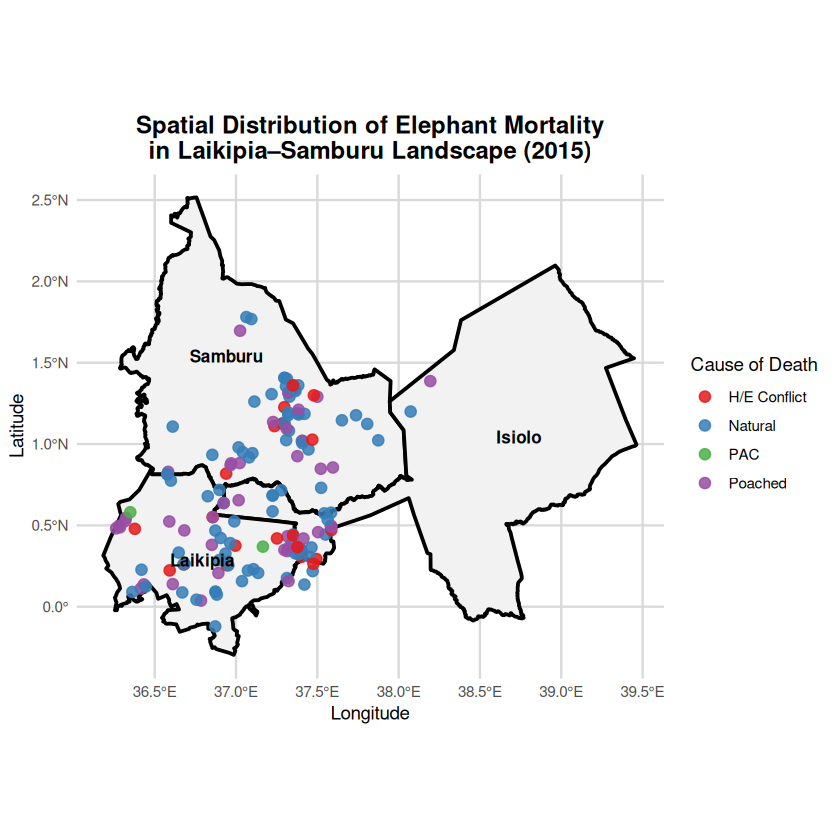

In [12]:
# STEP 6: Spatial Map of Elephant Mortality (RQ2)

# Read the shapefile
counties <- st_read("Laikipia_Samburu_Landscapezip/Laikipia_Samburu_Landscape.shp")

# Clean coordinates
data_points <- data_clean %>%
  filter(!is.na(latitude) & !is.na(longitude)) %>%
  mutate(
    Latitude = as.numeric(latitude),
    Longitude = as.numeric(longitude)
  )

# Plot map
ggplot() +
  
  # County polygons
  geom_sf(data = counties, fill = "grey95", color = "black", linewidth = 0.8) +
  
  # Elephant mortality points
  geom_point(
    data = data_points,
    aes(x = longitude, y = latitude, color = cause_of_death_simplified),
    size = 2.5,
    alpha = 0.85
  ) +
  
  # County labels
  geom_sf_text(data = counties, aes(label = COUNTY),
               size = 3.5, fontface = "bold") +
  
  # Colors for mortality causes
  scale_color_brewer(palette = "Set1") +
  
  # Map labels
  labs(
    title = "Spatial Distribution of Elephant Mortality\nin Laikipia–Samburu Landscape (2015)",
    x = "Longitude",
    y = "Latitude",
    color = "Cause of Death"
  ) +
  
  # Better theme
  theme_minimal() +
  
  theme(
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 11),
    legend.position = "right",
    panel.grid.major = element_line(color = "grey85")
  ) +
  
  coord_sf()

# A tibble: 2 × 2
  sex        n
  <chr>  <int>
1 Female    54
2 Male      99


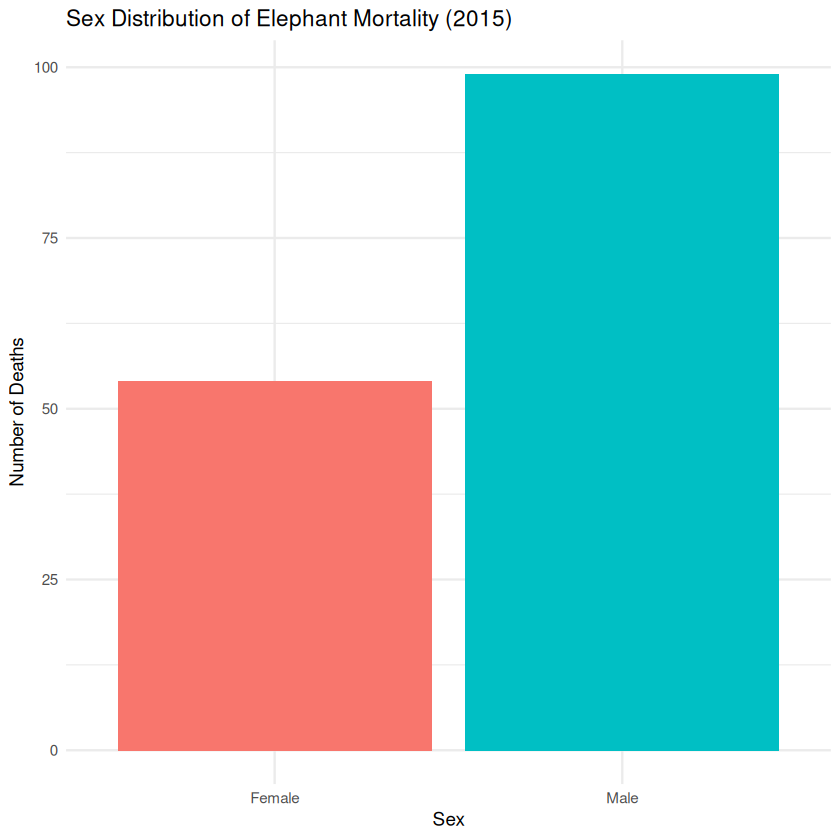

In [13]:
# SEX DISTRIBUTON (COUNTS + BAR CHART) (RQ3) (a)

# Sex distribution
sex_summary <- data_clean %>%
  filter(!is.na(sex)) %>%   # remove missing values
  count(sex)

print(sex_summary)

# Bar chart for sex
ggplot(sex_summary, aes(x = sex, y = n, fill = sex)) +
  geom_col() +
  labs(
    title = "Sex Distribution of Elephant Mortality (2015)",
    x = "Sex",
    y = "Number of Deaths"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

In [14]:
# CLEAN AND GROUP AGE (RQ3) (b1)

data_clean <- data_clean %>%
  mutate(
    age_clean = tolower(age),  # make everything lowercase
    
    # Extract first number from age (e.g., "15-20 yrs" -> 15)
    age_num = as.numeric(stringr::str_extract(age_clean, "\\d+")),
    
    # Create age groups
    age_group = case_when(
      age_num <= 10 ~ "Juvenile",
      age_num > 10 & age_num <= 20 ~ "Sub-adult",
      age_num > 20 ~ "Adult",
      TRUE ~ NA_character_
    ),
    
    # 🔹 Set correct order here
    age_group = factor(age_group, levels = c("Juvenile", "Sub-adult", "Adult"))
  )
table(data_clean$age_group)


 Juvenile Sub-adult     Adult 
       16        22        56 

# A tibble: 3 × 2
  age_group     n
  <fct>     <int>
1 Juvenile     16
2 Sub-adult    22
3 Adult        56


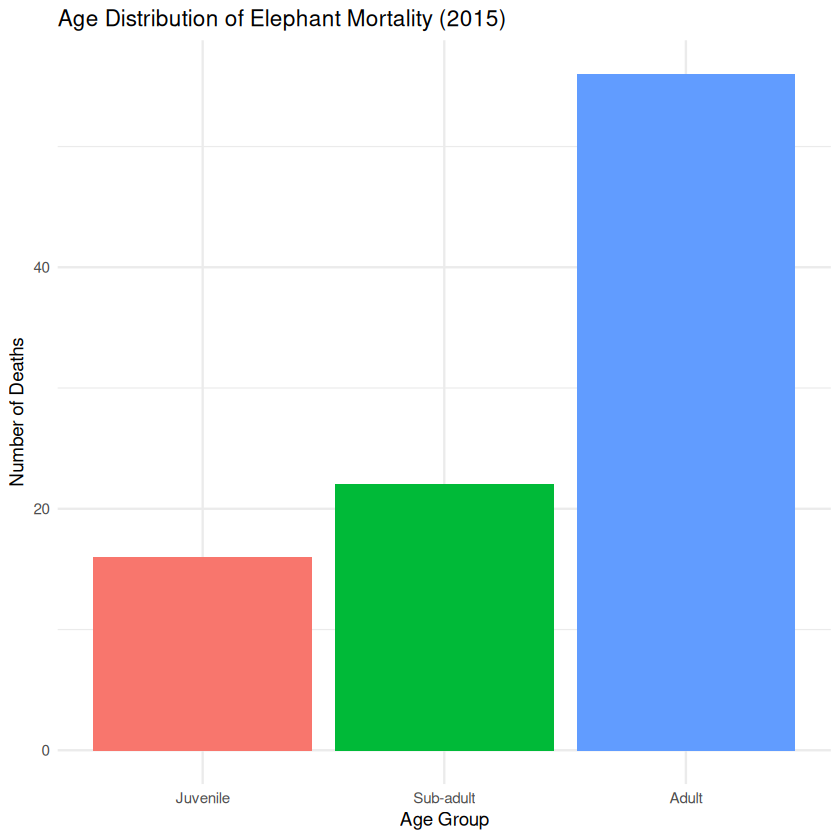

In [15]:
# AGE DISTRIBUTION (RQ3) (b2)

age_group_summary <- data_clean %>%
  filter(!is.na(age_group)) %>%
  count(age_group) %>%
  arrange(age_group)   # 🔹 ensures correct order

print(age_group_summary)

ggplot(age_group_summary, aes(x = age_group, y = n, fill = age_group)) +
  geom_col() +
  labs(
    title = "Age Distribution of Elephant Mortality (2015)",
    x = "Age Group",
    y = "Number of Deaths"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

# A tibble: 6 × 3
  sex    age_group     n
  <chr>  <fct>     <int>
1 Female Juvenile      5
2 Female Sub-adult     8
3 Female Adult        18
4 Male   Juvenile      9
5 Male   Sub-adult    14
6 Male   Adult        36


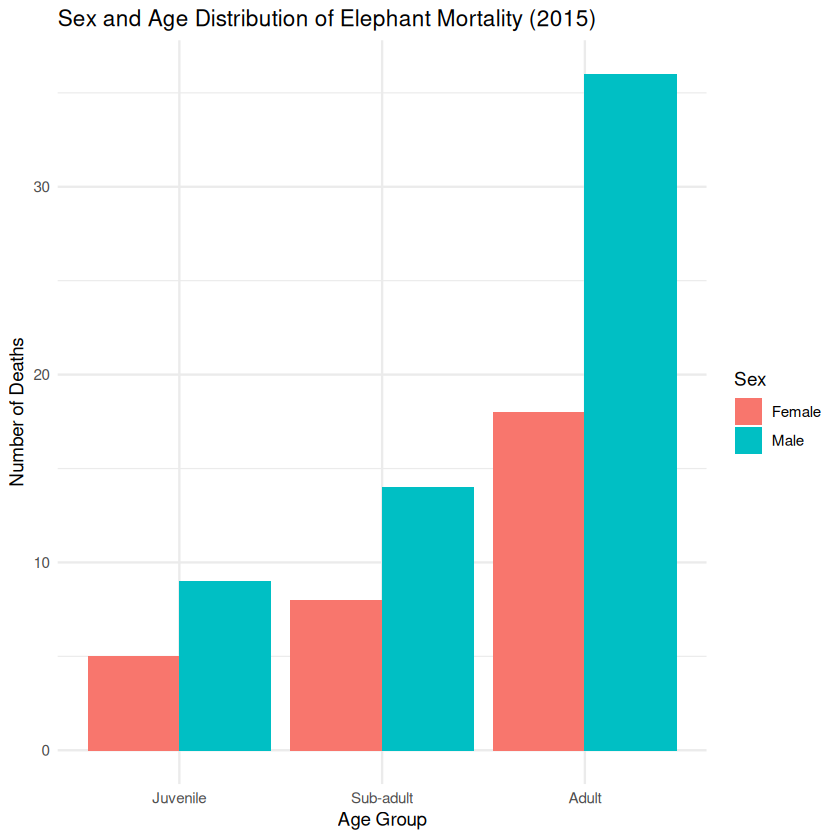

In [16]:
# SEX AND AGE COMBINED (RQ3) (c)

sex_age_summary <- data_clean %>%
  filter(!is.na(sex) & !is.na(age_group)) %>%   # use age_group
  count(sex, age_group)

print(sex_age_summary)

# Dodged bar chart (clean)
ggplot(sex_age_summary, aes(x = age_group, y = n, fill = sex)) +
  geom_col(position = "dodge") +
  labs(
    title = "Sex and Age Distribution of Elephant Mortality (2015)",
    x = "Age Group",
    y = "Number of Deaths",
    fill = "Sex"
  ) +
  theme_minimal()

In [17]:
# PROPORTION OF ILLEGAL KILLING VS NATURAL/OTHER (RQ4)

data_clean <- data_clean %>%
  mutate(illegal = case_when(
    cause_of_death_simplified %in% c("Poached", "H/E Conflict") ~ "Illegal Killing",
    TRUE ~ "Natural/Other"
  ))

prop_illegal <- data_clean %>%
  count(illegal) %>%
  mutate(proportion = n / sum(n) * 100)

print(prop_illegal)

# A tibble: 2 × 3
  illegal             n proportion
  <chr>           <int>      <dbl>
1 Illegal Killing    74       44.8
2 Natural/Other      91       55.2


Illegal killing accounted for 44.8% of recorded elephant deaths in 2015, while 55.2% were attributed to natural or other causes.


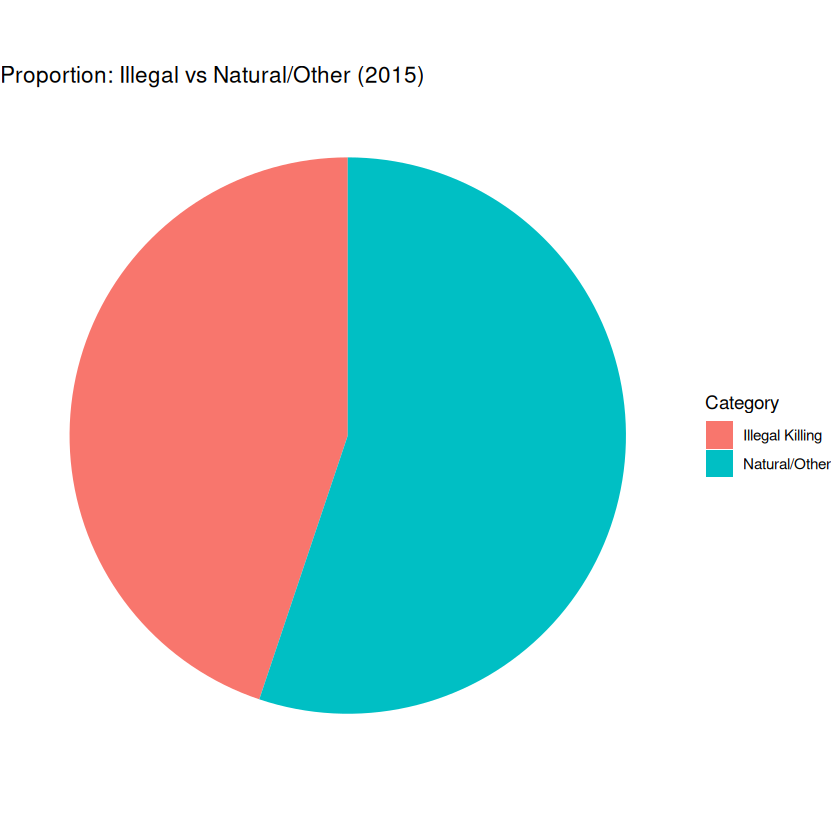

In [18]:
# Pie for proportions (RQ4)
ggplot(prop_illegal, aes(x = "", y = n, fill = illegal)) +
  geom_col() +
  coord_polar("y") +
  labs(title = "Proportion: Illegal vs Natural/Other (2015)", fill = "Category") +
  theme_void()